### 均匀线阵测量方位角
只能测量0-180度,否则出现栅瓣,容易出现左右舷分辨模糊(我们专业这么叫的)

In [1]:
import librosa
import numpy as np
import pyroomacoustics as pra

X = []
for i in range(6):
    wav, _ = librosa.load(f"./1_uniform_linear_array/mic{i+1}.wav", sr=16000)
    X.append(wav)
X = np.array(X)

#对每个通道stft
X_f = []
for m in range(6):
    stft = librosa.stft(X[m], n_fft=1024, hop_length=128)
    X_f.append(stft)

X_f = np.array(X_f)   # (6, 513, T)
print("频域数据:", X_f.shape)

linear_pos = np.array([
                [0,0],
                [0.05,0],
                [0.1,0],
                [0.15,0],
                [0.2,0],
                [0.25,0]
])
linear_doa = pra.doa.srp.SRP(L = linear_pos.T,
                             fs=16000, nfft=1024,
                             c=340.0,
                             num_src=1, mode='far',
                             r=None, azimuth=None,
                             colatitude=None,
                             n_grid=None, dim=2)

频域数据: (6, 513, 1487)


方位角135.0度


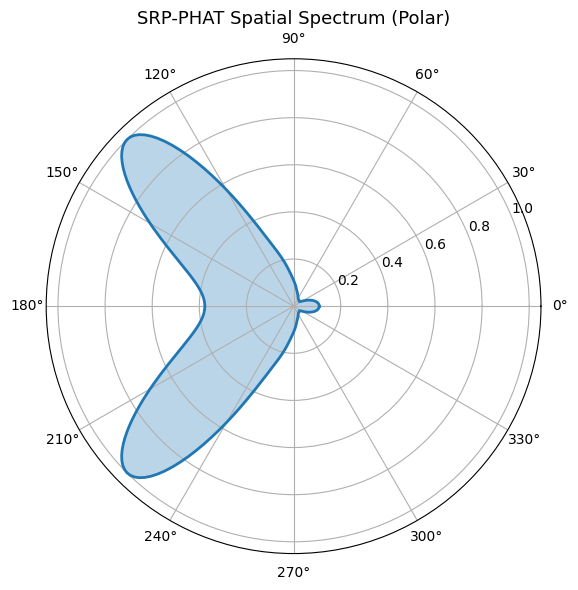

pyroomacoustics给出了另一半结果
Direction:225.0度


In [2]:
linear_doa.locate_sources(X_f)
import matplotlib.pyplot as plt

# 取出 SRP 网格
theta = linear_doa.grid.azimuth        # (N,)  弧度
P = linear_doa.grid.values             # (N,)  SRP 能量

# 归一化
P = P / np.max(P)

source_idx = np.argmax(P)
rad = theta[source_idx]
print(f"方位角{np.rad2deg(rad)}度")


# 极坐标绘图
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

ax.plot(theta, P, linewidth=2)
ax.fill(theta, P, alpha=0.3)



# 坐标 & 风格设置
ax.set_theta_zero_location("E")   # 0° 在右侧（阵列 x 轴）
ax.set_theta_direction(1)        # 顺时针为正角
ax.set_thetagrids(range(0, 360, 30))
ax.set_rlim(0, 1.05)

ax.set_title("SRP-PHAT Spatial Spectrum (Polar)", fontsize=13)
plt.tight_layout()
plt.show()
print("pyroomacoustics给出了另一半结果")
print(f"Direction:{np.rad2deg(linear_doa.azimuth_recon).item()}度")


### 圆阵测量方位角

In [3]:
X = []
for i in range(6):
    wav, _ = librosa.load(f"./2_uniform_circular_array/mic{i+1}.wav", sr=16000)
    X.append(wav)
X = np.array(X)

#对每个通道stft
X_f = []
for m in range(6):
    stft = librosa.stft(X[m], n_fft=1024, hop_length=128)
    X_f.append(stft)

X_f = np.array(X_f)   # (6, 513, T)
print("频域数据:", X_f.shape)
R = 0.05
circular_pos = np.array([
                [0.05,0],
                [R*np.cos(np.deg2rad(60)),R*np.sin(np.deg2rad(60))],
                [R*np.cos(np.deg2rad(120)),R*np.sin(np.deg2rad(120))],
                [R*np.cos(np.deg2rad(180)),R*np.sin(np.deg2rad(180))],
                [R*np.cos(np.deg2rad(240)),R*np.sin(np.deg2rad(240))],
                [R*np.cos(np.deg2rad(300)),R*np.sin(np.deg2rad(300))]
])
circular_doa = pra.doa.srp.SRP(L = circular_pos.T,
                             fs=16000, nfft=1024,
                             c=340.0,
                             num_src=1, mode='far',
                             r=None, azimuth=None,
                             colatitude=None,
                             n_grid=None, dim=2)

频域数据: (6, 513, 1487)


方位角59.99999999999999度


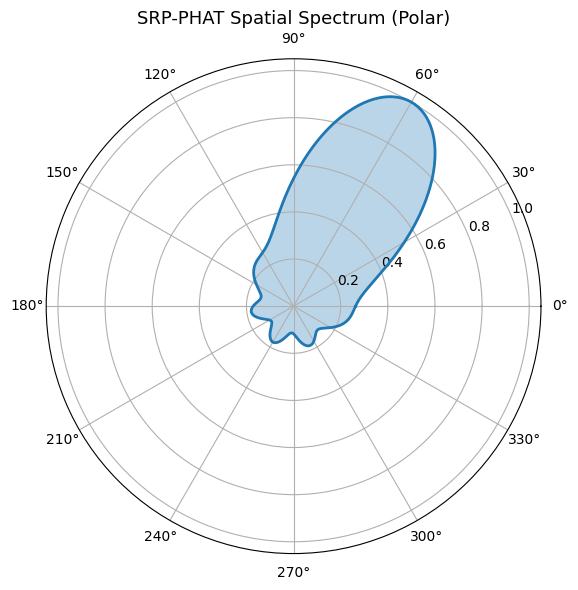

Direction:59.99999999999999度


In [4]:
circular_doa.locate_sources(X_f)
import matplotlib.pyplot as plt

# 取出 SRP 网格
theta = circular_doa.grid.azimuth        # (N,)  弧度
P = circular_doa.grid.values             # (N,)  SRP 能量

# 归一化
P = P / np.max(P)

source_idx = np.argmax(P)
rad = theta[source_idx]
print(f"方位角{np.rad2deg(rad)}度")

# 极坐标绘图
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

ax.plot(theta, P, linewidth=2)
ax.fill(theta, P, alpha=0.3)



# 坐标 & 风格设置
ax.set_theta_zero_location("E")   # 0° 在右侧（阵列 x 轴）
ax.set_theta_direction(1)        # 顺时针为正角
ax.set_thetagrids(range(0, 360, 30))
ax.set_rlim(0, 1.05)

ax.set_title("SRP-PHAT Spatial Spectrum (Polar)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Direction:{np.rad2deg(circular_doa.azimuth_recon).item()}度")